# So sánh Data: Hiệu vs Tiến

So sánh dữ liệu cảm biến (accelerometer + gyroscope) tự thu từ **ESP32-C3 + MPU6050**
giữa 2 người: **Hiệu** và **Tiến**.

- Device: ESP32-C3 + MPU6050 + MAX30102
- Sample rate: 50Hz, Kalman-filtered
- Accel: m/s² | Gyro: rad/s

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

# ==================== PATHS ====================
BASE = os.path.join('..', 'server', 'data')
HIEU_DIR = os.path.join(BASE, 'Hieu')
TIEN_DIR = os.path.join(BASE, 'Tien')

print('Hieu dir exists:', os.path.isdir(HIEU_DIR))
print('Tien dir exists:', os.path.isdir(TIEN_DIR))

Hieu dir exists: True
Tien dir exists: True


## 1. Load Data

In [2]:
def load_person_data(person_dir, person_name):
    """Load data theo cau truc cu va moi:
    - Cu: person/Fall_or_Normal/session/{accel,gyro,features}.csv
    - Moi: person/Fall_or_Normal/activity/session/{accel,gyro,features}.csv
    """
    accel_frames = []
    gyro_frames = []
    features_frames = []
    session_info = []

    for label_type in ['Fall', 'Normal']:
        label_dir = os.path.join(person_dir, label_type)
        if not os.path.isdir(label_dir):
            continue

        for first_level in sorted(os.listdir(label_dir)):
            first_dir = os.path.join(label_dir, first_level)
            if not os.path.isdir(first_dir):
                continue

            # Truong hop 1: first_level da la 1 session (cau truc cu)
            direct_files = [
                os.path.exists(os.path.join(first_dir, 'accel.csv')),
                os.path.exists(os.path.join(first_dir, 'gyro.csv')),
                os.path.exists(os.path.join(first_dir, 'features.csv')),
            ]

            session_targets = []
            if any(direct_files):
                session_targets.append((first_level, first_dir, first_level))
            else:
                # Truong hop 2: first_level la ten hoat dong, ben trong moi la session
                activity_name = first_level
                for sess in sorted(os.listdir(first_dir)):
                    sess_dir = os.path.join(first_dir, sess)
                    if not os.path.isdir(sess_dir):
                        continue
                    session_name = f'{activity_name}/{sess}'
                    session_targets.append((session_name, sess_dir, activity_name))

            for session_name, sess_dir, activity_name in session_targets:
                accel_path = os.path.join(sess_dir, 'accel.csv')
                gyro_path = os.path.join(sess_dir, 'gyro.csv')
                features_path = os.path.join(sess_dir, 'features.csv')

                n_accel = 0
                n_gyro = 0

                if os.path.exists(accel_path):
                    try:
                        df_a = pd.read_csv(accel_path)
                        df_a['person'] = person_name
                        df_a['session'] = session_name
                        df_a['activity'] = label_type
                        df_a['activity_name'] = activity_name
                        accel_frames.append(df_a)
                        n_accel = len(df_a)
                    except Exception as e:
                        print(f'  Skip accel {session_name}: {e}')

                if os.path.exists(gyro_path):
                    try:
                        df_g = pd.read_csv(gyro_path)
                        df_g['person'] = person_name
                        df_g['session'] = session_name
                        df_g['activity'] = label_type
                        df_g['activity_name'] = activity_name
                        gyro_frames.append(df_g)
                        n_gyro = len(df_g)
                    except Exception as e:
                        print(f'  Skip gyro {session_name}: {e}')

                if os.path.exists(features_path):
                    try:
                        df_f = pd.read_csv(features_path)
                        df_f['person'] = person_name
                        df_f['session'] = session_name
                        df_f['activity'] = label_type
                        df_f['activity_name'] = activity_name
                        features_frames.append(df_f)
                    except Exception as e:
                        print(f'  Skip features {session_name}: {e}')

                session_info.append({
                    'person': person_name,
                    'session': session_name,
                    'activity': label_type,
                    'activity_name': activity_name,
                    'n_accel_samples': n_accel,
                    'n_gyro_samples': n_gyro
                })

    accel_df = pd.concat(accel_frames, ignore_index=True) if accel_frames else pd.DataFrame()
    gyro_df = pd.concat(gyro_frames, ignore_index=True) if gyro_frames else pd.DataFrame()
    features_df = pd.concat(features_frames, ignore_index=True) if features_frames else pd.DataFrame()
    sessions_df = pd.DataFrame(session_info)

    return accel_df, gyro_df, features_df, sessions_df


# Load data
hieu_accel, hieu_gyro, hieu_feat, hieu_sess = load_person_data(HIEU_DIR, 'Hieu')
tien_accel, tien_gyro, tien_feat, tien_sess = load_person_data(TIEN_DIR, 'Tien')

# Compute magnitude
for df in [hieu_accel, tien_accel]:
    if not df.empty:
        df['mag'] = np.sqrt(df['accel_x_list']**2 + df['accel_y_list']**2 + df['accel_z_list']**2)

for df in [hieu_gyro, tien_gyro]:
    if not df.empty:
        df['gmag'] = np.sqrt(df['gyro_x_list']**2 + df['gyro_y_list']**2 + df['gyro_z_list']**2)

print(f'Hieu: {len(hieu_accel)} accel samples, {len(hieu_feat)} feature windows')
print(f'Tien: {len(tien_accel)} accel samples, {len(tien_feat)} feature windows')

for name, sess in [('Hieu', hieu_sess), ('Tien', tien_sess)]:
    print(f'\n{name} - activities:')
    if sess.empty:
        print('  No session data')
        continue
    display(sess.groupby(['activity', 'activity_name'])['session'].count().rename('n_sessions').reset_index())

Hieu: 46800 accel samples, 468 feature windows
Tien: 4900 accel samples, 49 feature windows

Hieu - activities:


,activity,activity_name,n_sessions
0,Fall,LonXon,10
1,Fall,NgaRaSau,16
2,Fall,NgaRaTruoc,20
3,Normal,ChayBoCham,13
4,Normal,DiBo,5
5,Normal,GoPhim,10
6,Normal,LonXon,21
7,Normal,LuotDienThoai,10



Tien - activities:


,activity,activity_name,n_sessions
0,Fall,LonXon,12


## 2. Tổng quan Sessions

TONG QUAN SESSIONS


sessions  total_accel_samples  avg_samples_per_session
person activity                                                        
Hieu   Fall            46                17000                    370.0
       Normal          59                29800                    505.0
Tien   Fall            12                 4900                    408.0

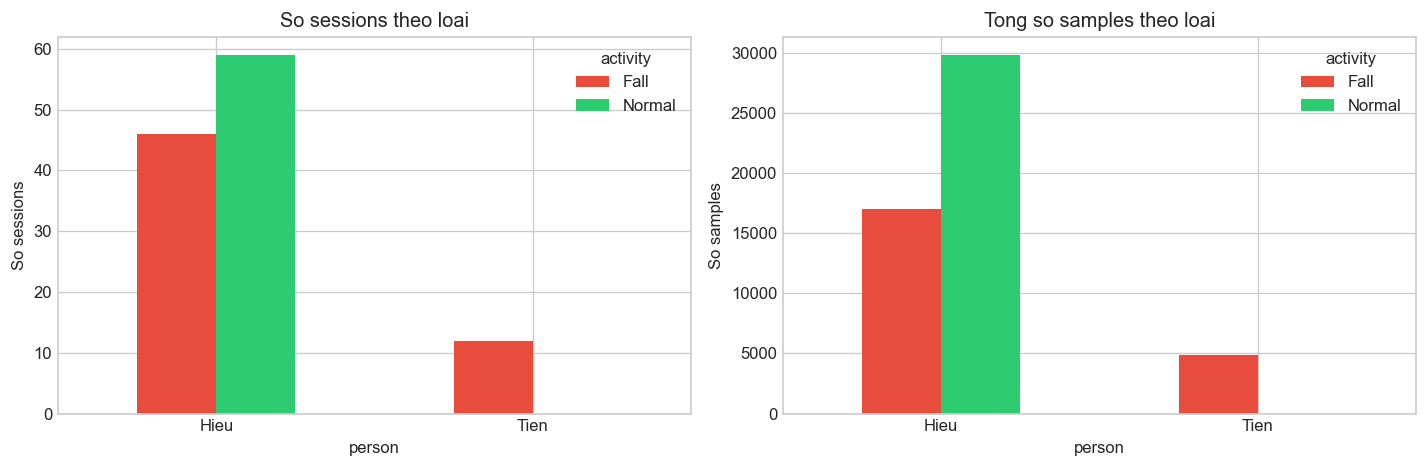

In [3]:
all_sess = pd.concat([hieu_sess, tien_sess], ignore_index=True)

summary = all_sess.groupby(['person', 'activity']).agg(
    sessions=('session', 'count'),
    total_accel_samples=('n_accel_samples', 'sum'),
    avg_samples_per_session=('n_accel_samples', 'mean')
).round(0)

print('=' * 60)
print('TONG QUAN SESSIONS')
print('=' * 60)
display(summary)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Session counts
pivot_count = all_sess.groupby(['person', 'activity'])['session'].count().unstack(fill_value=0)
pivot_count.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('So sessions theo loai')
axes[0].set_ylabel('So sessions')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Total samples
pivot_samples = all_sess.groupby(['person', 'activity'])['n_accel_samples'].sum().unstack(fill_value=0)
pivot_samples.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Tong so samples theo loai')
axes[1].set_ylabel('So samples')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 3. So sánh phân phối Accelerometer

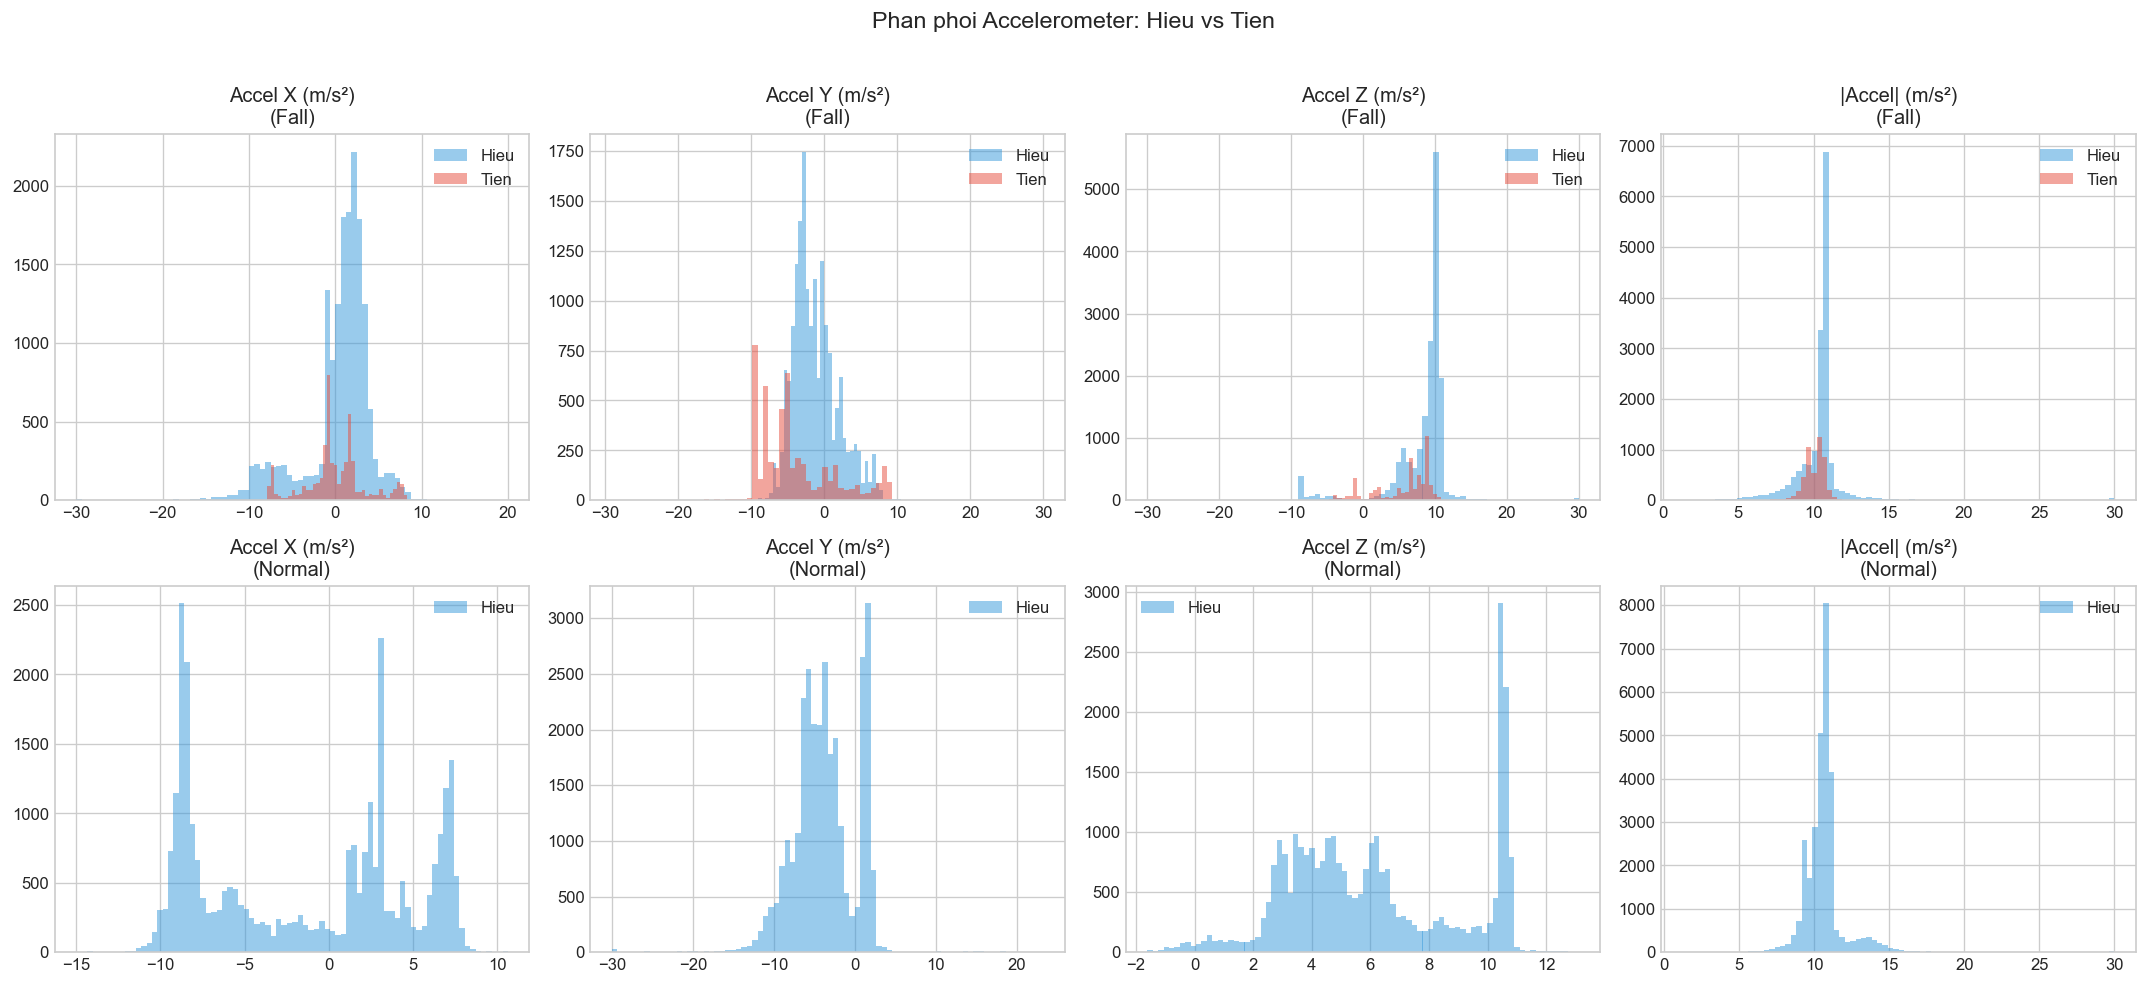

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

accel_cols = ['accel_x_list', 'accel_y_list', 'accel_z_list', 'mag']
accel_labels = ['Accel X (m/s\u00b2)', 'Accel Y (m/s\u00b2)', 'Accel Z (m/s\u00b2)', '|Accel| (m/s\u00b2)']
colors = {'Hieu': '#3498db', 'Tien': '#e74c3c'}

for j, (col, label) in enumerate(zip(accel_cols, accel_labels)):
    # Fall data
    for i, (name, df) in enumerate([('Hieu', hieu_accel), ('Tien', tien_accel)]):
        fall_data = df[df['activity'] == 'Fall']
        if not fall_data.empty and col in fall_data.columns:
            axes[0, j].hist(fall_data[col].clip(-30, 30), bins=80, alpha=0.5,
                           label=name, color=colors[name], edgecolor='none')
    axes[0, j].set_title(f'{label}\n(Fall)')
    axes[0, j].legend()

    # Normal data
    for i, (name, df) in enumerate([('Hieu', hieu_accel), ('Tien', tien_accel)]):
        normal_data = df[df['activity'] == 'Normal']
        if not normal_data.empty and col in normal_data.columns:
            axes[1, j].hist(normal_data[col].clip(-30, 30), bins=80, alpha=0.5,
                           label=name, color=colors[name], edgecolor='none')
    axes[1, j].set_title(f'{label}\n(Normal)')
    axes[1, j].legend()

plt.suptitle('Phan phoi Accelerometer: Hieu vs Tien', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. So sánh phân phối Gyroscope

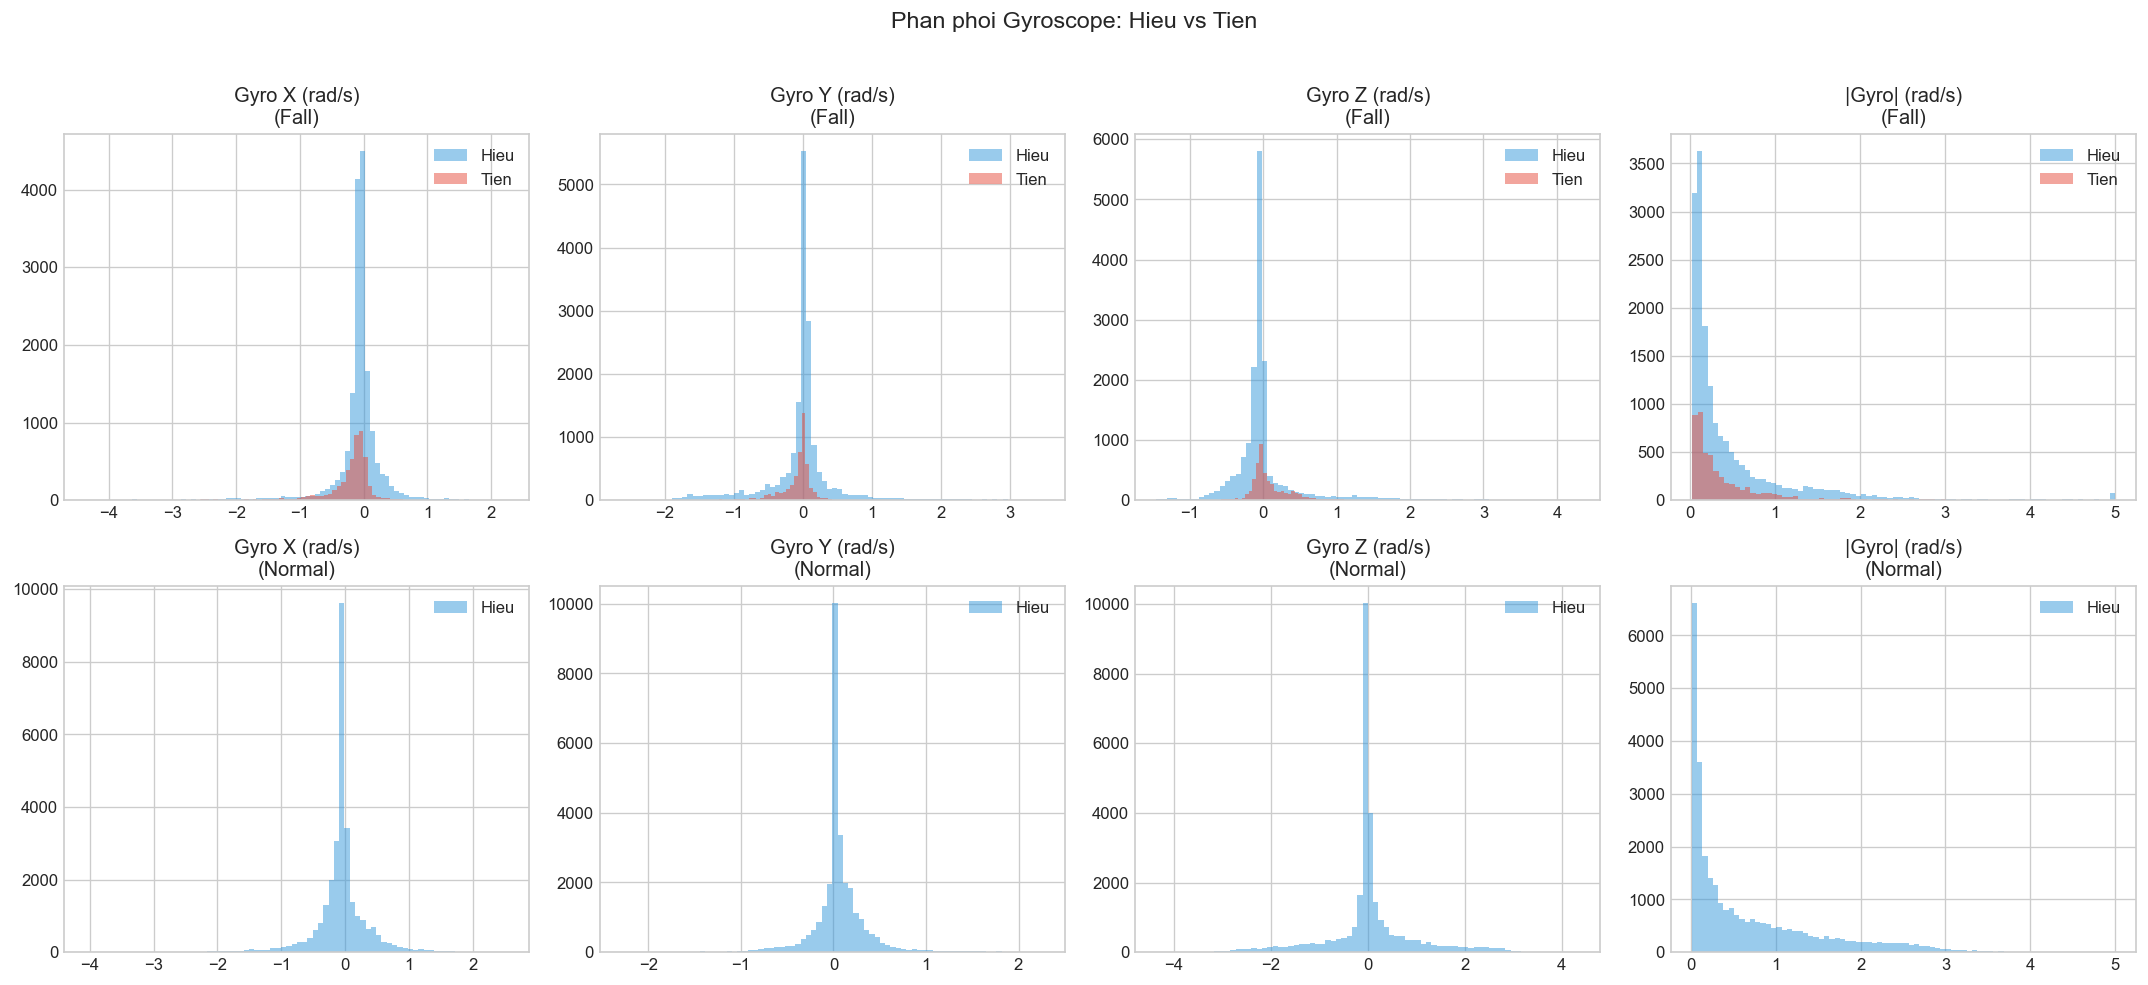

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

gyro_cols = ['gyro_x_list', 'gyro_y_list', 'gyro_z_list', 'gmag']
gyro_labels = ['Gyro X (rad/s)', 'Gyro Y (rad/s)', 'Gyro Z (rad/s)', '|Gyro| (rad/s)']

for j, (col, label) in enumerate(zip(gyro_cols, gyro_labels)):
    # Fall
    for name, df in [('Hieu', hieu_gyro), ('Tien', tien_gyro)]:
        fall_data = df[df['activity'] == 'Fall']
        if not fall_data.empty and col in fall_data.columns:
            axes[0, j].hist(fall_data[col].clip(-5, 5), bins=80, alpha=0.5,
                           label=name, color=colors[name], edgecolor='none')
    axes[0, j].set_title(f'{label}\n(Fall)')
    axes[0, j].legend()

    # Normal
    for name, df in [('Hieu', hieu_gyro), ('Tien', tien_gyro)]:
        normal_data = df[df['activity'] == 'Normal']
        if not normal_data.empty and col in normal_data.columns:
            axes[1, j].hist(normal_data[col].clip(-5, 5), bins=80, alpha=0.5,
                           label=name, color=colors[name], edgecolor='none')
    axes[1, j].set_title(f'{label}\n(Normal)')
    axes[1, j].legend()

plt.suptitle('Phan phoi Gyroscope: Hieu vs Tien', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Thống kê chi tiết

In [6]:
def compute_person_stats(accel_df, gyro_df, name):
    """Tinh thong ke cho 1 nguoi, chia theo Fall/Normal."""
    rows = []
    for activity in ['Fall', 'Normal']:
        a_sub = accel_df[accel_df['activity'] == activity] if not accel_df.empty else pd.DataFrame()
        g_sub = gyro_df[gyro_df['activity'] == activity] if not gyro_df.empty else pd.DataFrame()

        if a_sub.empty:
            continue

        rows.append({
            'Person': name,
            'Activity': activity,
            'Samples': len(a_sub),
            'Sessions': a_sub['session'].nunique(),
            'Mag Mean': a_sub['mag'].mean(),
            'Mag Std': a_sub['mag'].std(),
            'Mag Max': a_sub['mag'].max(),
            'Accel X Mean': a_sub['accel_x_list'].mean(),
            'Accel Y Mean': a_sub['accel_y_list'].mean(),
            'Accel Z Mean': a_sub['accel_z_list'].mean(),
            'Gyro Mag Mean': g_sub['gmag'].mean() if not g_sub.empty and 'gmag' in g_sub.columns else np.nan,
            'Gyro Mag Std': g_sub['gmag'].std() if not g_sub.empty and 'gmag' in g_sub.columns else np.nan,
        })
    return rows

stats_rows = []
stats_rows.extend(compute_person_stats(hieu_accel, hieu_gyro, 'Hieu'))
stats_rows.extend(compute_person_stats(tien_accel, tien_gyro, 'Tien'))

stats_df = pd.DataFrame(stats_rows).round(4)
print('=' * 80)
print('THONG KE CHI TIET: HIEU vs TIEN')
print('=' * 80)
display(stats_df)

THONG KE CHI TIET: HIEU vs TIEN


,Person,Activity,Samples,Sessions,Mag Mean,Mag Std,Mag Max,Accel X Mean,Accel Y Mean,Accel Z Mean,Gyro Mag Mean,Gyro Mag Std
0,Hieu,Fall,17000,46,10.4469,2.2039,60.4479,0.3736,-1.2096,8.1538,0.5029,0.7419
1,Hieu,Normal,29800,59,10.6901,1.6590,34.3089,-1.4773,-3.6637,6.1876,0.6918,0.8044
2,Tien,Fall,4900,12,10.1567,1.6225,55.6142,-0.0093,-3.9164,5.5312,0.4503,0.6105


## 6. So sánh Features (magnitude_avg, sma, max_accel, ...)

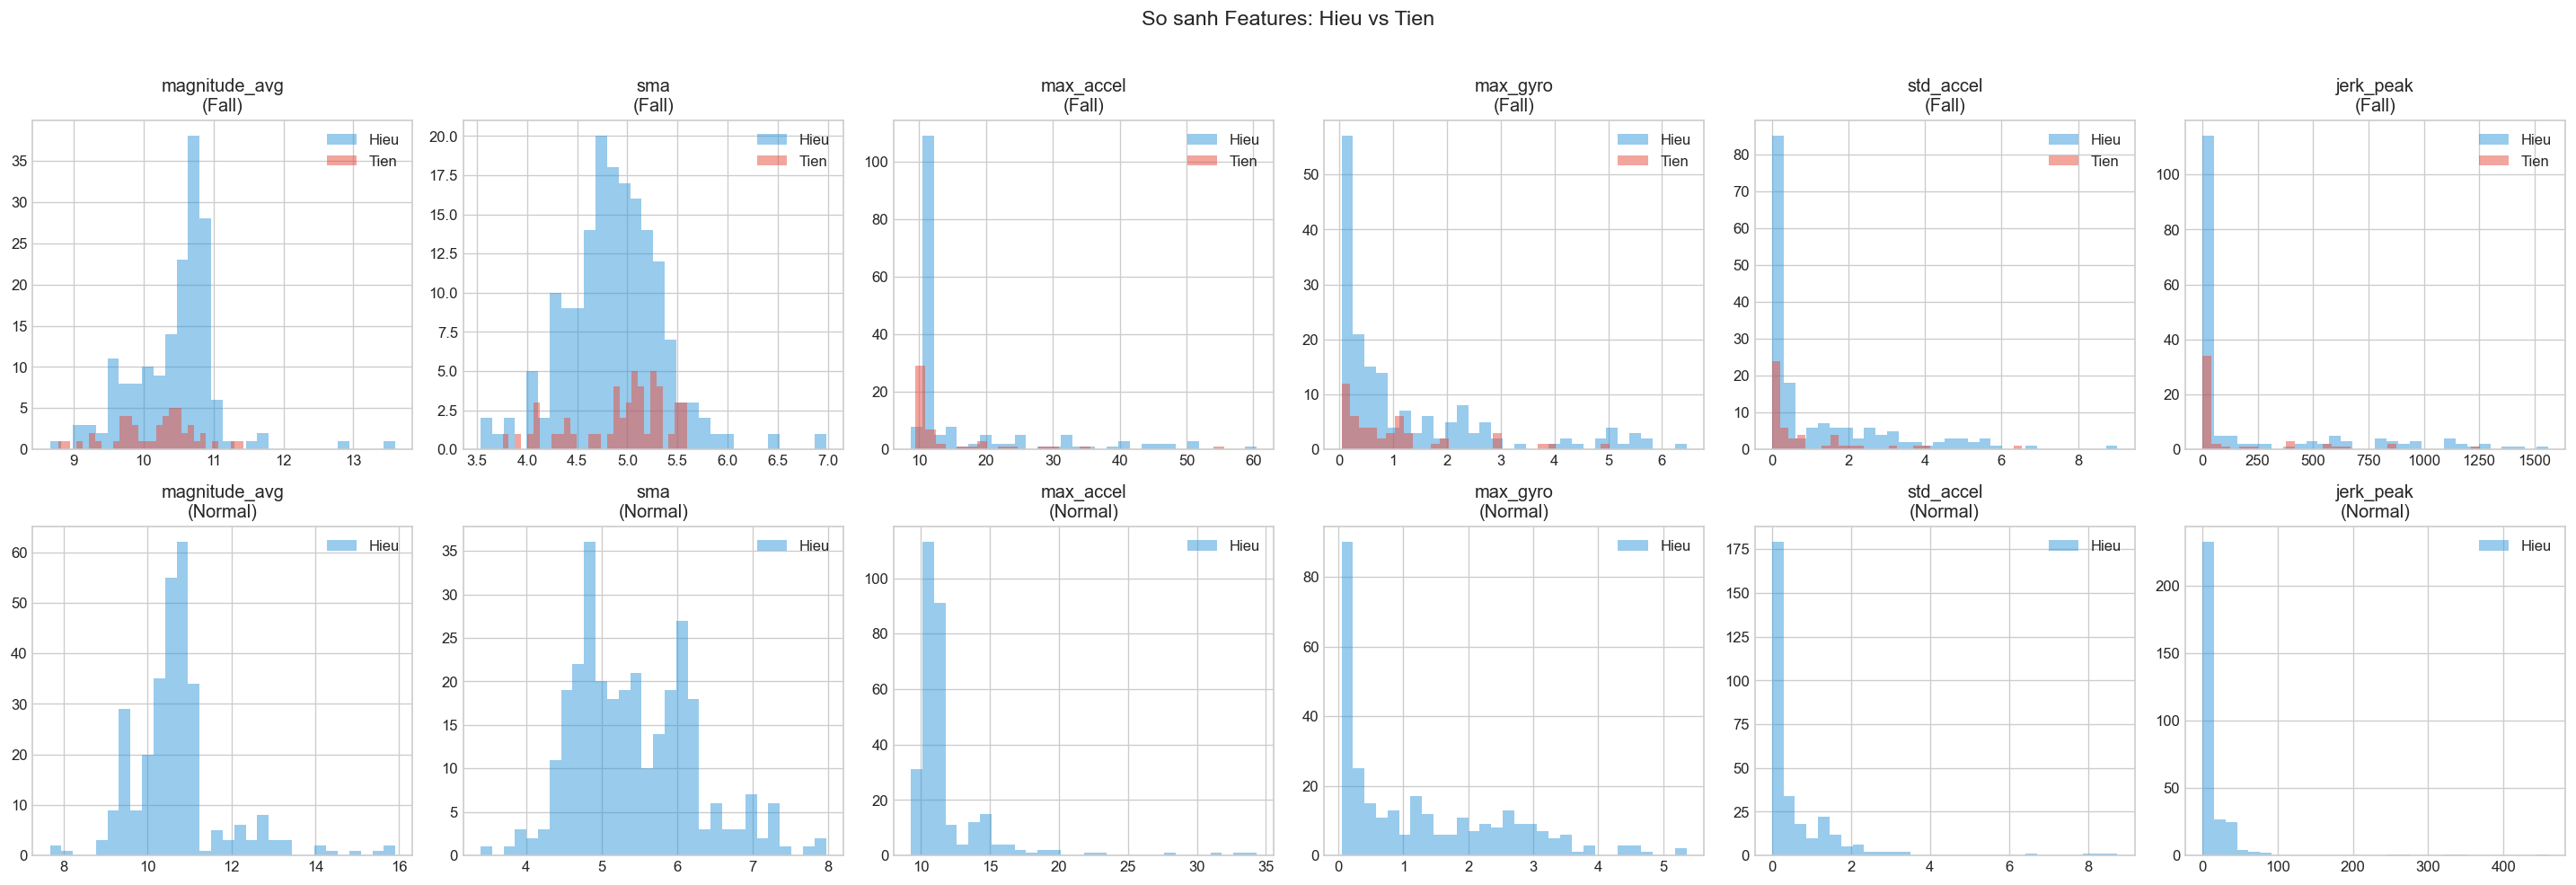

In [7]:
all_feat = pd.concat([hieu_feat, tien_feat], ignore_index=True)

feat_cols = ['magnitude_avg', 'sma', 'max_accel', 'max_gyro', 'std_accel', 'jerk_peak']
feat_cols_available = [c for c in feat_cols if c in all_feat.columns]

if feat_cols_available:
    n_cols = len(feat_cols_available)
    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))
    if n_cols == 1:
        axes = axes.reshape(-1, 1)

    for j, col in enumerate(feat_cols_available):
        # Fall
        for name in ['Hieu', 'Tien']:
            subset = all_feat[(all_feat['person'] == name) & (all_feat['activity'] == 'Fall')]
            if not subset.empty:
                axes[0, j].hist(subset[col].dropna(), bins=30, alpha=0.5,
                               label=name, color=colors[name], edgecolor='none')
        axes[0, j].set_title(f'{col}\n(Fall)')
        axes[0, j].legend()

        # Normal
        for name in ['Hieu', 'Tien']:
            subset = all_feat[(all_feat['person'] == name) & (all_feat['activity'] == 'Normal')]
            if not subset.empty:
                axes[1, j].hist(subset[col].dropna(), bins=30, alpha=0.5,
                               label=name, color=colors[name], edgecolor='none')
        axes[1, j].set_title(f'{col}\n(Normal)')
        axes[1, j].legend()

    plt.suptitle('So sanh Features: Hieu vs Tien', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Khong co feature columns de so sanh.')

## 7. Box Plot so sánh tổng hợp

C:\Users\Admin\AppData\Local\Temp\ipykernel_28288\1459021189.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(box_data_a, labels=box_labels_a, patch_artist=True, showfliers=False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_28288\1459021189.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(box_data_g, labels=box_labels_g, patch_artist=True, showfliers=False)


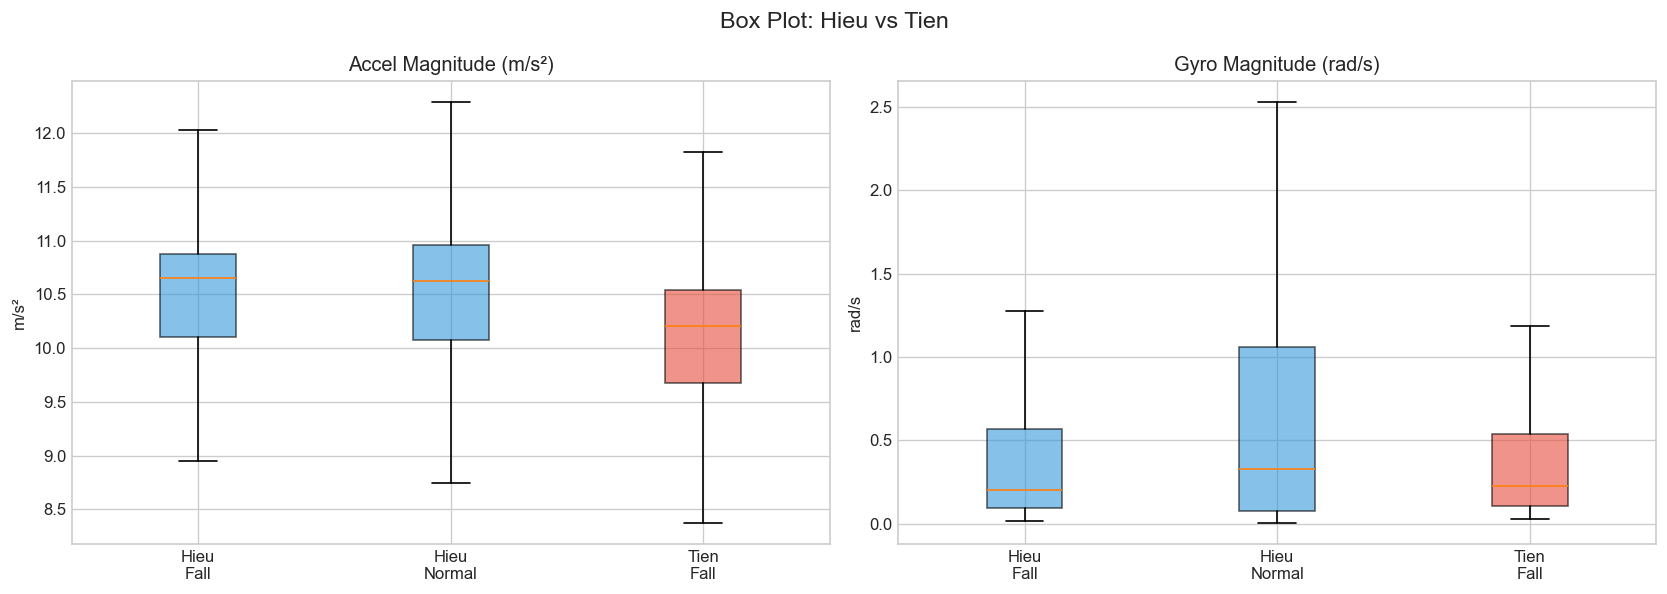

In [8]:
all_accel = pd.concat([hieu_accel, tien_accel], ignore_index=True)
all_gyro = pd.concat([hieu_gyro, tien_gyro], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accel magnitude boxplot
groups = all_accel.groupby(['person', 'activity'])
box_data_a = []
box_labels_a = []
box_colors_a = []
color_map = {'Hieu': '#3498db', 'Tien': '#e74c3c'}
for (person, activity), grp in groups:
    if 'mag' in grp.columns:
        box_data_a.append(grp['mag'].values)
        box_labels_a.append(f'{person}\n{activity}')
        box_colors_a.append(color_map.get(person, '#999'))

if box_data_a:
    bp1 = axes[0].boxplot(box_data_a, labels=box_labels_a, patch_artist=True, showfliers=False)
    for patch, c in zip(bp1['boxes'], box_colors_a):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    axes[0].set_title('Accel Magnitude (m/s\u00b2)')
    axes[0].set_ylabel('m/s\u00b2')

# Gyro magnitude boxplot
groups_g = all_gyro.groupby(['person', 'activity'])
box_data_g = []
box_labels_g = []
box_colors_g = []
for (person, activity), grp in groups_g:
    if 'gmag' in grp.columns:
        box_data_g.append(grp['gmag'].values)
        box_labels_g.append(f'{person}\n{activity}')
        box_colors_g.append(color_map.get(person, '#999'))

if box_data_g:
    bp2 = axes[1].boxplot(box_data_g, labels=box_labels_g, patch_artist=True, showfliers=False)
    for patch, c in zip(bp2['boxes'], box_colors_g):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    axes[1].set_title('Gyro Magnitude (rad/s)')
    axes[1].set_ylabel('rad/s')

plt.suptitle('Box Plot: Hieu vs Tien', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Time-series mẫu: 1 session Fall của mỗi người

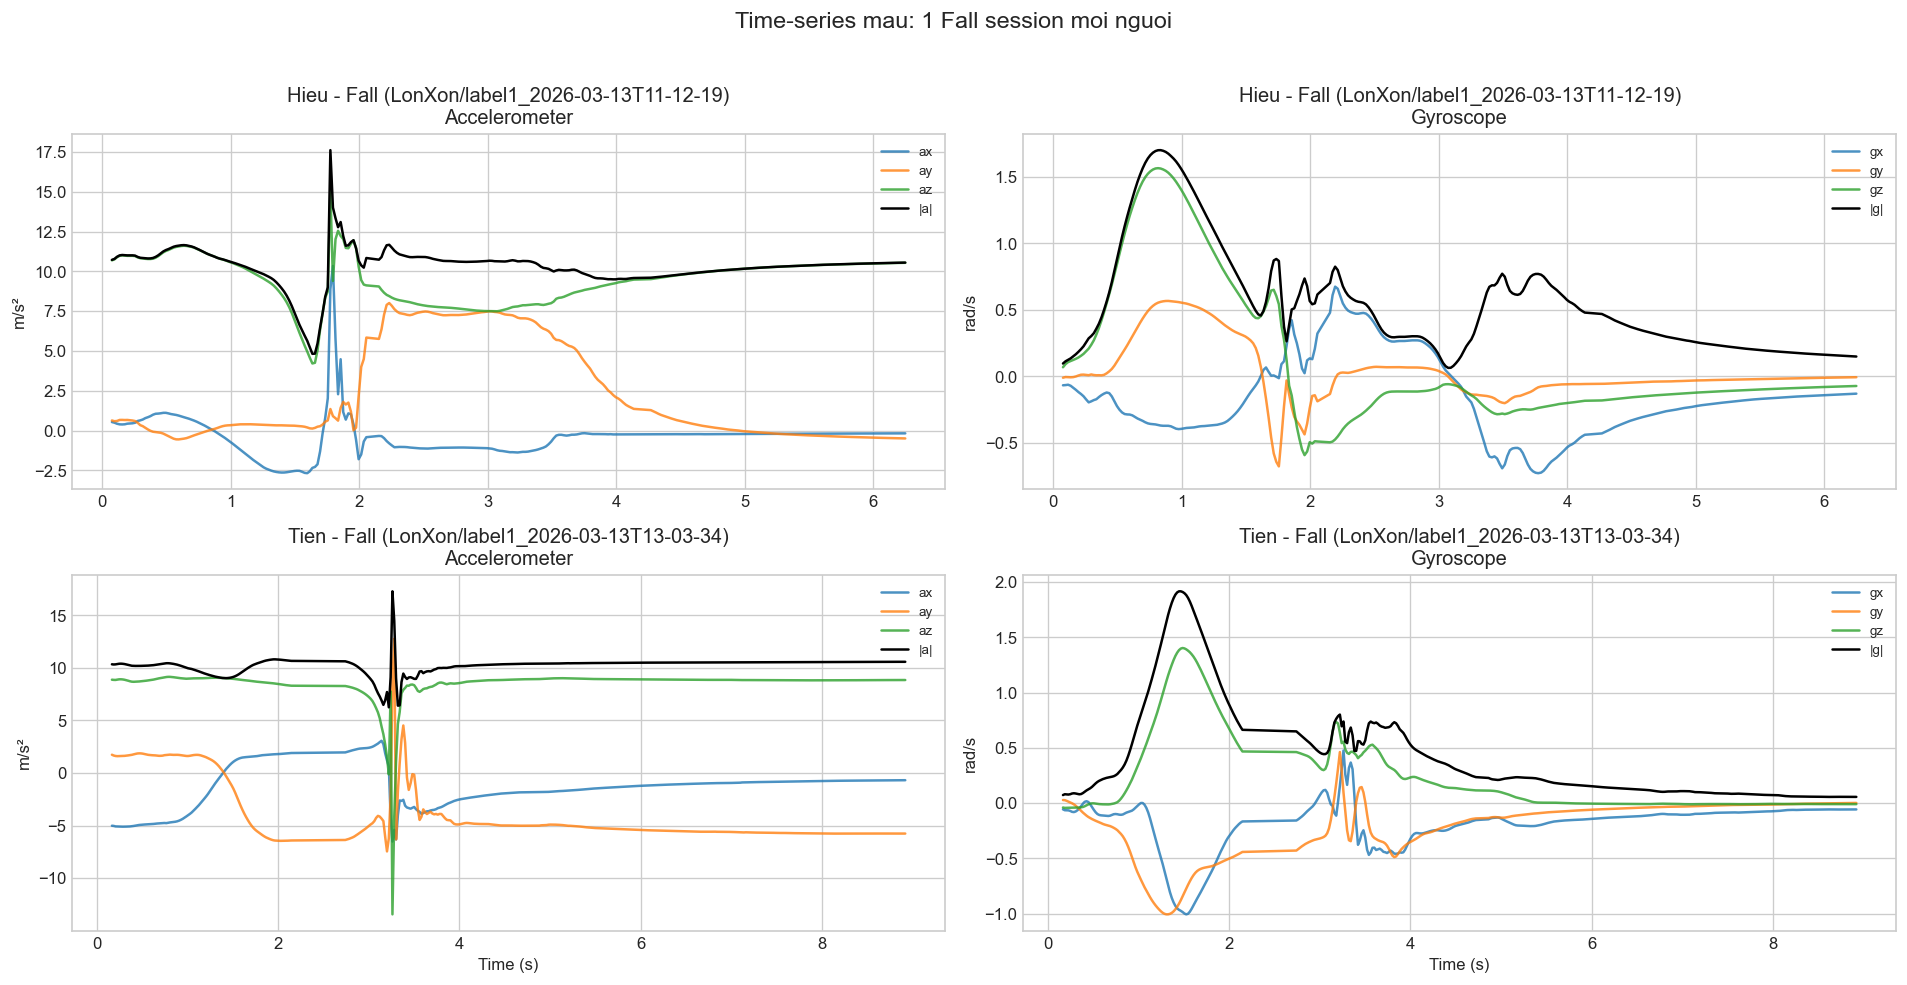

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for i, (name, accel_df, gyro_df) in enumerate([('Hieu', hieu_accel, hieu_gyro),
                                                ('Tien', tien_accel, tien_gyro)]):
    fall_sessions = accel_df[accel_df['activity'] == 'Fall']['session'].unique()
    if len(fall_sessions) == 0:
        axes[i, 0].text(0.5, 0.5, f'{name}: No Fall data', ha='center', va='center',
                        transform=axes[i, 0].transAxes)
        continue

    sess = fall_sessions[0]
    a_seg = accel_df[accel_df['session'] == sess]
    g_seg = gyro_df[gyro_df['session'] == sess]

    # Accel
    t = a_seg['accel_time_list'].values
    axes[i, 0].plot(t, a_seg['accel_x_list'], label='ax', alpha=0.8)
    axes[i, 0].plot(t, a_seg['accel_y_list'], label='ay', alpha=0.8)
    axes[i, 0].plot(t, a_seg['accel_z_list'], label='az', alpha=0.8)
    axes[i, 0].plot(t, a_seg['mag'], label='|a|', color='black', lw=1.5)
    axes[i, 0].set_title(f'{name} - Fall ({sess})\nAccelerometer')
    axes[i, 0].set_ylabel('m/s\u00b2')
    axes[i, 0].legend(loc='upper right', fontsize=8)

    # Gyro
    if not g_seg.empty:
        t_g = g_seg['gyro_time_list'].values
        axes[i, 1].plot(t_g, g_seg['gyro_x_list'], label='gx', alpha=0.8)
        axes[i, 1].plot(t_g, g_seg['gyro_y_list'], label='gy', alpha=0.8)
        axes[i, 1].plot(t_g, g_seg['gyro_z_list'], label='gz', alpha=0.8)
        axes[i, 1].plot(t_g, g_seg['gmag'], label='|g|', color='black', lw=1.5)
        axes[i, 1].set_title(f'{name} - Fall ({sess})\nGyroscope')
        axes[i, 1].set_ylabel('rad/s')
        axes[i, 1].legend(loc='upper right', fontsize=8)

axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
plt.suptitle('Time-series mau: 1 Fall session moi nguoi', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. So sánh Features trung bình theo người (Radar Chart)

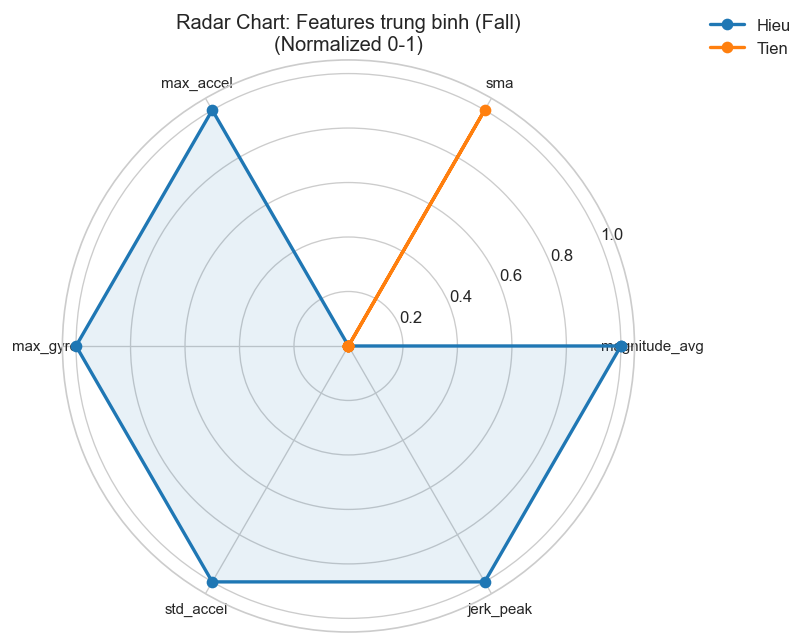


Gia tri trung binh (Fall sessions):


,magnitude_avg,sma,max_accel,max_gyro,std_accel,jerk_peak
person,,,,,,
Hieu,10.4469,4.8727,16.1833,1.2366,1.2262,218.9228
Tien,10.1567,4.9350,14.1689,1.0152,0.8104,150.5408


In [10]:
radar_cols = ['magnitude_avg', 'sma', 'max_accel', 'max_gyro', 'std_accel', 'jerk_peak']
radar_available = [c for c in radar_cols if c in all_feat.columns]

if len(radar_available) >= 3:
    # Tinh mean theo person + activity (chi Fall)
    fall_feat = all_feat[all_feat['activity'] == 'Fall']
    if not fall_feat.empty:
        means = fall_feat.groupby('person')[radar_available].mean()

        # Normalize ve 0-1 de radar chart dep hon
        mins = means.min()
        maxs = means.max()
        rng = maxs - mins
        rng[rng == 0] = 1
        means_norm = (means - mins) / rng

        angles = np.linspace(0, 2 * np.pi, len(radar_available), endpoint=False).tolist()
        angles += angles[:1]  # close the polygon

        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
        for person in means_norm.index:
            values = means_norm.loc[person].tolist()
            values += values[:1]
            ax.plot(angles, values, 'o-', label=person, linewidth=2)
            ax.fill(angles, values, alpha=0.1)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(radar_available, fontsize=9)
        ax.set_title('Radar Chart: Features trung binh (Fall)\n(Normalized 0-1)', fontsize=12)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
        plt.tight_layout()
        plt.show()

        # Hien bang raw values
        print('\nGia tri trung binh (Fall sessions):')
        display(means.round(4))
    else:
        print('Khong co Fall features de ve radar chart.')
else:
    print(f'Chi co {len(radar_available)} features, can it nhat 3 de ve radar chart.')

## 10. Kết luận

In [11]:
print('=' * 60)
print('KET LUAN SO SANH: HIEU vs TIEN')
print('=' * 60)

for name, accel_df, gyro_df, feat_df, sess_df in [
    ('Hieu', hieu_accel, hieu_gyro, hieu_feat, hieu_sess),
    ('Tien', tien_accel, tien_gyro, tien_feat, tien_sess)
]:
    print(f'\n--- {name} ---')
    n_fall = len(sess_df[sess_df['activity'] == 'Fall'])
    n_normal = len(sess_df[sess_df['activity'] == 'Normal'])
    print(f'  Sessions: {n_fall} Fall, {n_normal} Normal')
    print(f'  Accel samples: {len(accel_df)}')
    if not accel_df.empty and 'mag' in accel_df.columns:
        print(f'  Accel mag: mean={accel_df["mag"].mean():.2f}, std={accel_df["mag"].std():.2f}, max={accel_df["mag"].max():.2f}')
    if not gyro_df.empty and 'gmag' in gyro_df.columns:
        print(f'  Gyro mag: mean={gyro_df["gmag"].mean():.2f}, std={gyro_df["gmag"].std():.2f}, max={gyro_df["gmag"].max():.2f}')
    if not feat_df.empty:
        fall_feat = feat_df[feat_df['activity'] == 'Fall']
        if not fall_feat.empty and 'max_accel' in fall_feat.columns:
            print(f'  Fall max_accel: mean={fall_feat["max_accel"].mean():.2f}, max={fall_feat["max_accel"].max():.2f}')
        if not fall_feat.empty and 'jerk_peak' in fall_feat.columns:
            print(f'  Fall jerk_peak: mean={fall_feat["jerk_peak"].mean():.2f}, max={fall_feat["jerk_peak"].max():.2f}')

print('\n' + '=' * 60)
print('Luu y:')
print('- Cung thiet bi ESP32-C3 + MPU6050, 50Hz, Kalman-filtered')
print('- Su khac biet den tu the trang, cach nga, vi tri deo cam bien')
print('=' * 60)

KET LUAN SO SANH: HIEU vs TIEN

--- Hieu ---
  Sessions: 46 Fall, 59 Normal
  Accel samples: 46800
  Accel mag: mean=10.60, std=1.88, max=60.45
  Gyro mag: mean=0.62, std=0.79, max=6.46
  Fall max_accel: mean=16.18, max=60.45
  Fall jerk_peak: mean=218.92, max=1561.18

--- Tien ---
  Sessions: 12 Fall, 0 Normal
  Accel samples: 4900
  Accel mag: mean=10.16, std=1.62, max=55.61
  Gyro mag: mean=0.45, std=0.61, max=5.02
  Fall max_accel: mean=14.17, max=55.61
  Fall jerk_peak: mean=150.54, max=1254.12

Luu y:
- Cung thiet bi ESP32-C3 + MPU6050, 50Hz, Kalman-filtered
- Su khac biet den tu the trang, cach nga, vi tri deo cam bien


## 11. So sánh Hiếu và Tiến theo hoạt động chung

Hoat dong chung giua Hieu va Tien: ['LonXon']


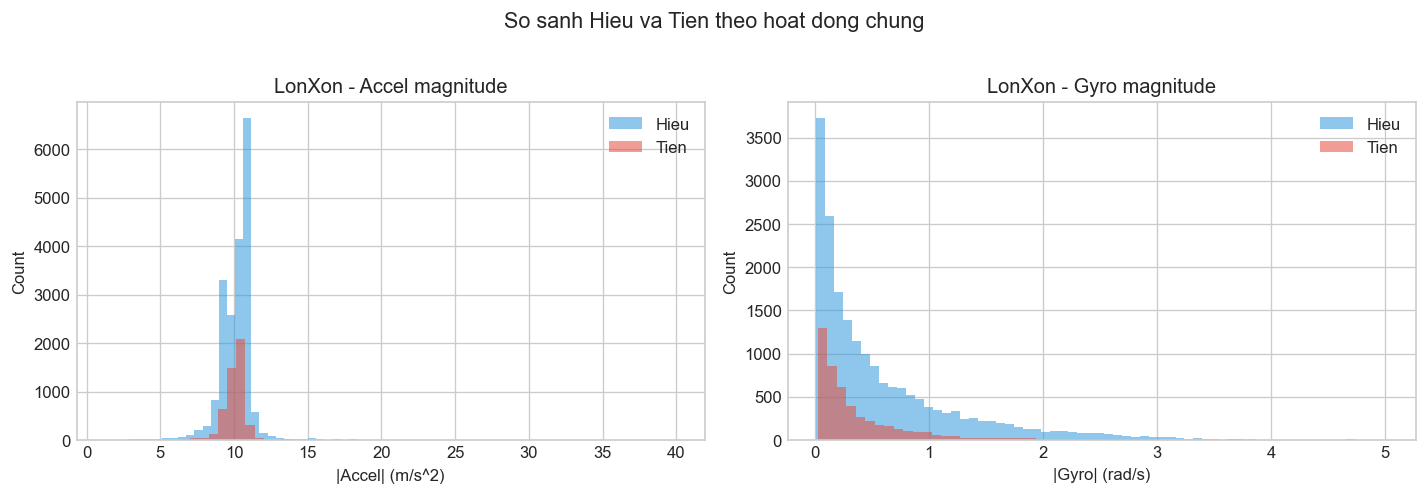

In [12]:
def plot_common_activity_comparison(hieu_accel, hieu_gyro, tien_accel, tien_gyro):
    hieu_acts = set(hieu_accel['activity_name'].unique()) if not hieu_accel.empty else set()
    tien_acts = set(tien_accel['activity_name'].unique()) if not tien_accel.empty else set()
    common_acts = sorted(hieu_acts.intersection(tien_acts))

    print('Hoat dong chung giua Hieu va Tien:', common_acts if common_acts else 'Khong co')

    if not common_acts:
        print('Khong co hoat dong chung de so sanh theo activity_name.')
        return

    fig, axes = plt.subplots(len(common_acts), 2, figsize=(12, 4 * len(common_acts)))
    if len(common_acts) == 1:
        axes = np.array([axes])

    for i, act in enumerate(common_acts):
        ha = hieu_accel[hieu_accel['activity_name'] == act]
        ta = tien_accel[tien_accel['activity_name'] == act]
        hg = hieu_gyro[hieu_gyro['activity_name'] == act]
        tg = tien_gyro[tien_gyro['activity_name'] == act]

        axes[i, 0].hist(ha['mag'].clip(0, 40), bins=60, alpha=0.55, label='Hieu', color='#3498db', edgecolor='none')
        axes[i, 0].hist(ta['mag'].clip(0, 40), bins=60, alpha=0.55, label='Tien', color='#e74c3c', edgecolor='none')
        axes[i, 0].set_title(f'{act} - Accel magnitude')
        axes[i, 0].set_xlabel('|Accel| (m/s^2)')
        axes[i, 0].set_ylabel('Count')
        axes[i, 0].legend()

        if not hg.empty and not tg.empty:
            axes[i, 1].hist(hg['gmag'].clip(0, 8), bins=60, alpha=0.55, label='Hieu', color='#3498db', edgecolor='none')
            axes[i, 1].hist(tg['gmag'].clip(0, 8), bins=60, alpha=0.55, label='Tien', color='#e74c3c', edgecolor='none')
            axes[i, 1].set_title(f'{act} - Gyro magnitude')
            axes[i, 1].set_xlabel('|Gyro| (rad/s)')
            axes[i, 1].set_ylabel('Count')
            axes[i, 1].legend()
        else:
            axes[i, 1].text(0.5, 0.5, 'Thieu gyro de so sanh', ha='center', va='center', transform=axes[i, 1].transAxes)
            axes[i, 1].set_title(f'{act} - Gyro magnitude')

    plt.suptitle('So sanh Hieu va Tien theo hoat dong chung', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


plot_common_activity_comparison(hieu_accel, hieu_gyro, tien_accel, tien_gyro)

## 12. Trực quan dữ liệu Hiếu theo từng hoạt động

,activity,activity_name,n_sessions,total_accel_samples
2,Fall,NgaRaTruoc,20,7600
1,Fall,NgaRaSau,16,5100
0,Fall,LonXon,10,4300
6,Normal,LonXon,21,15200
3,Normal,ChayBoCham,13,4300
5,Normal,GoPhim,10,4100
7,Normal,LuotDienThoai,10,4100
4,Normal,DiBo,5,2100


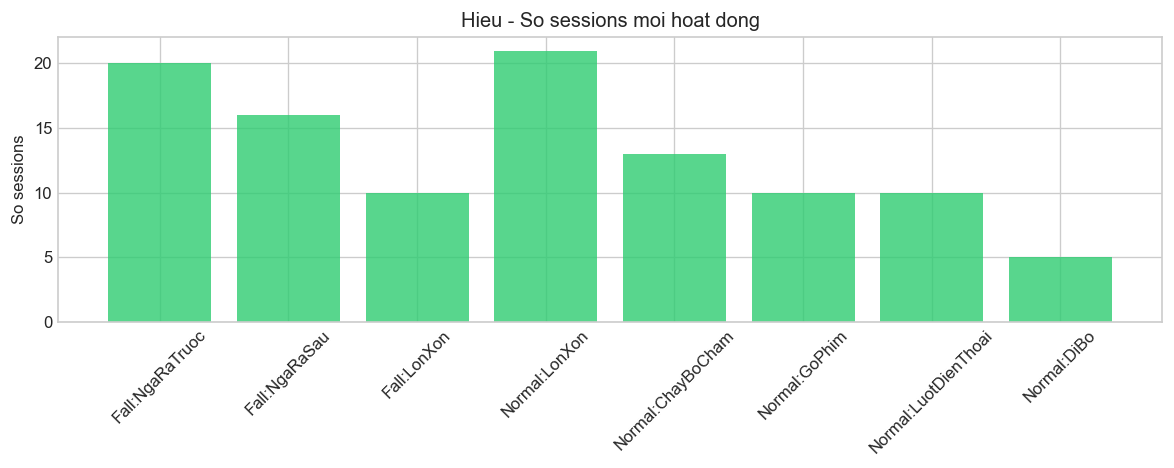

C:\Users\Admin\AppData\Local\Temp\ipykernel_28288\1737456034.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(box_data, labels=act_names, patch_artist=True, showfliers=False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_28288\1737456034.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(box_data, labels=act_names, patch_artist=True, showfliers=False)


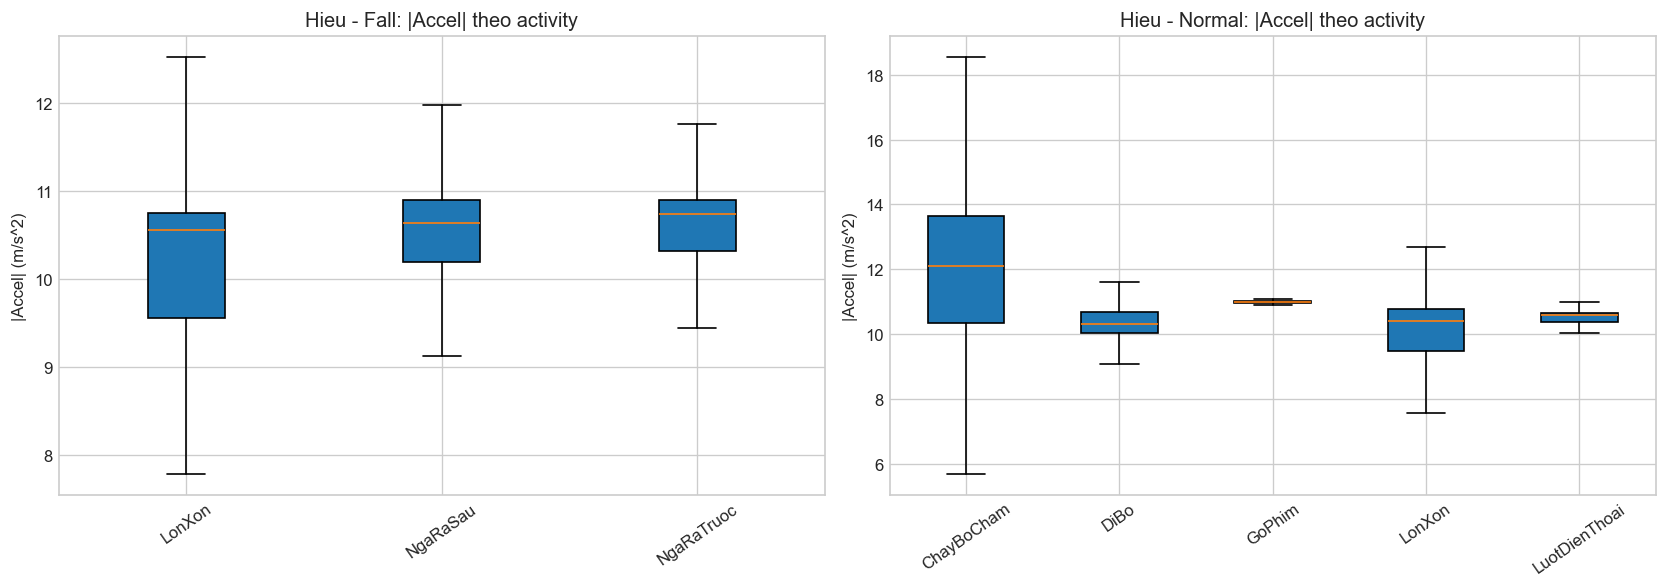

In [13]:
if hieu_sess.empty:
    print('Khong co du lieu Hieu.')
else:
    hieu_activity_table = (
        hieu_sess.groupby(['activity', 'activity_name'])
        .agg(
            n_sessions=('session', 'count'),
            total_accel_samples=('n_accel_samples', 'sum')
        )
        .reset_index()
        .sort_values(['activity', 'n_sessions'], ascending=[True, False])
    )
    display(hieu_activity_table)

    # Bar chart so session theo activity
    fig, ax = plt.subplots(figsize=(10, 4))
    labels = [f"{r['activity']}:{r['activity_name']}" for _, r in hieu_activity_table.iterrows()]
    ax.bar(labels, hieu_activity_table['n_sessions'], color='#2ecc71', alpha=0.8)
    ax.set_title('Hieu - So sessions moi hoat dong')
    ax.set_ylabel('So sessions')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # Boxplot accel magnitude theo activity_name (tach Fall/Normal)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for idx, label_type in enumerate(['Fall', 'Normal']):
        sub = hieu_accel[hieu_accel['activity'] == label_type]
        act_names = sorted(sub['activity_name'].dropna().unique())

        box_data = [sub[sub['activity_name'] == a]['mag'].values for a in act_names]
        if box_data and len(act_names) > 0:
            axes[idx].boxplot(box_data, labels=act_names, patch_artist=True, showfliers=False)
            axes[idx].set_title(f'Hieu - {label_type}: |Accel| theo activity')
            axes[idx].set_ylabel('|Accel| (m/s^2)')
            axes[idx].tick_params(axis='x', rotation=35)
        else:
            axes[idx].text(0.5, 0.5, f'Khong co data {label_type}', ha='center', va='center', transform=axes[idx].transAxes)

    plt.tight_layout()
    plt.show()

## 13. So sánh các cặp hoạt động cụ thể của Hiếu

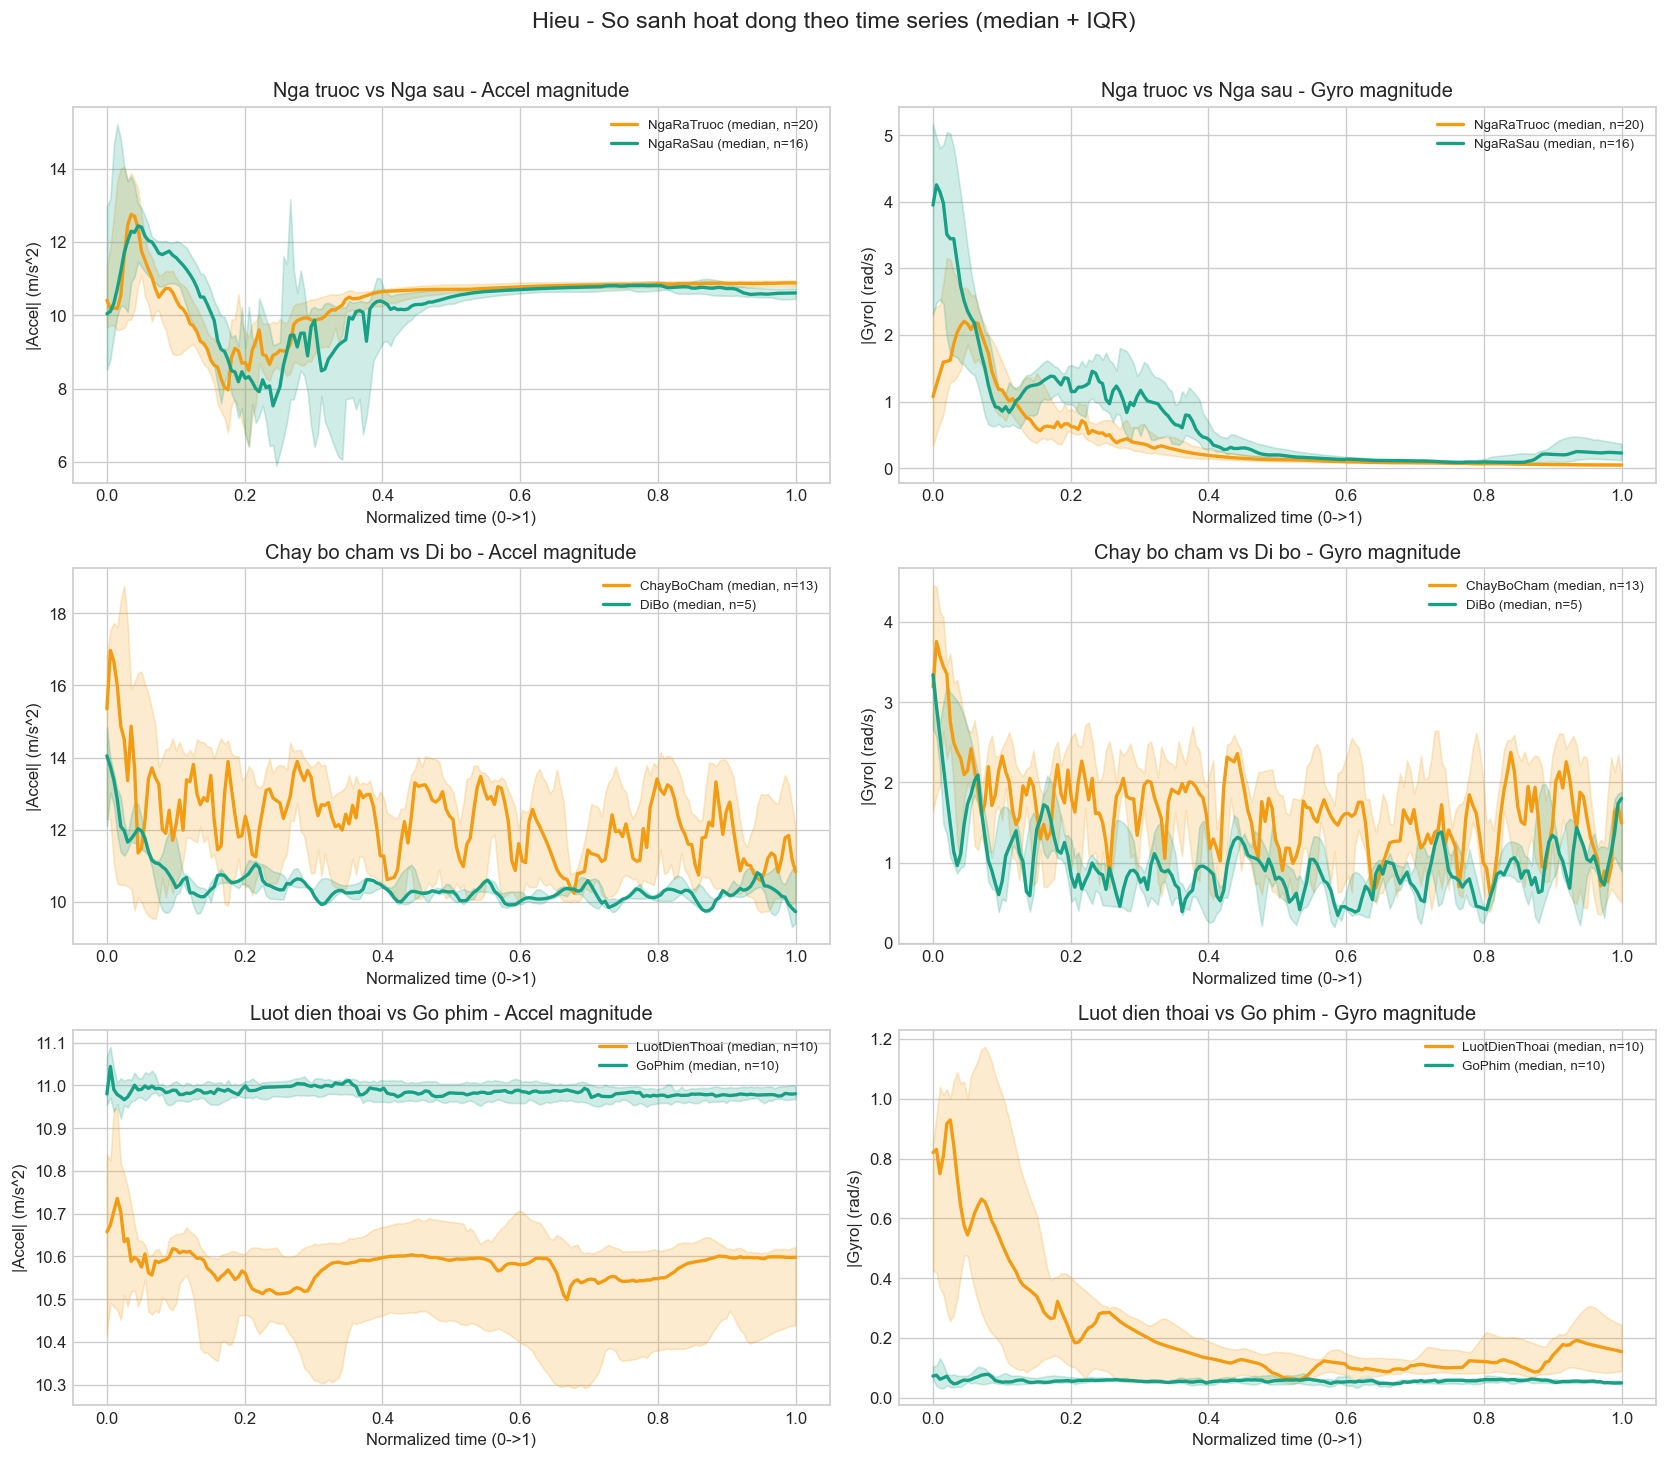

In [16]:
def _extract_session_series(df, session_name, time_col, value_col):
    seg = df[df['session'] == session_name].sort_values(time_col)
    if seg.empty or value_col not in seg.columns or time_col not in seg.columns:
        return None

    t = seg[time_col].to_numpy(dtype=float)
    v = seg[value_col].to_numpy(dtype=float)

    if len(t) < 5:
        return None

    # Dua time ve moc 0 de so sanh hinh dang chuoi theo thoi gian
    t = t - t[0]
    if t[-1] <= 0:
        return None

    return t, v


def _build_normalized_stack(df, activity_name, time_col, value_col, n_points=200):
    sessions = sorted(df[df['activity_name'] == activity_name]['session'].unique())
    if len(sessions) == 0:
        return None

    t_norm = np.linspace(0, 1, n_points)
    series_stack = []

    for sess in sessions:
        result = _extract_session_series(df, sess, time_col, value_col)
        if result is None:
            continue
        t, v = result

        # Chuan hoa truc thoi gian ve [0, 1] de so duoc cac session do dai khac nhau
        t01 = t / t[-1]
        y_interp = np.interp(t_norm, t01, v)
        series_stack.append(y_interp)

    if not series_stack:
        return None

    arr = np.vstack(series_stack)
    return {
        't': t_norm,
        'median': np.median(arr, axis=0),
        'q25': np.percentile(arr, 25, axis=0),
        'q75': np.percentile(arr, 75, axis=0),
        'n_sessions_used': arr.shape[0]
    }


def _plot_pair_time_series(ax, df, act_a, act_b, time_col, value_col, y_label, title):
    a = _build_normalized_stack(df, act_a, time_col, value_col)
    b = _build_normalized_stack(df, act_b, time_col, value_col)

    if a is None or b is None:
        ax.text(0.5, 0.5, f'Thieu data time-series\n{act_a} hoac {act_b}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    ax.plot(a['t'], a['median'], color='#f39c12', lw=2, label=f'{act_a} (median, n={a["n_sessions_used"]})')
    ax.fill_between(a['t'], a['q25'], a['q75'], color='#f39c12', alpha=0.2)

    ax.plot(b['t'], b['median'], color='#16a085', lw=2, label=f'{act_b} (median, n={b["n_sessions_used"]})')
    ax.fill_between(b['t'], b['q25'], b['q75'], color='#16a085', alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel('Normalized time (0->1)')
    ax.set_ylabel(y_label)
    ax.legend(loc='best', fontsize=8)


def compare_hieu_pairs_time_series(hieu_accel, hieu_gyro):
    pairs = [
        ('NgaRaTruoc', 'NgaRaSau', 'Nga truoc vs Nga sau'),
        ('ChayBoCham', 'DiBo', 'Chay bo cham vs Di bo'),
        ('LuotDienThoai', 'GoPhim', 'Luot dien thoai vs Go phim')
    ]

    fig, axes = plt.subplots(len(pairs), 2, figsize=(14, 4 * len(pairs)))
    if len(pairs) == 1:
        axes = np.array([axes])

    for i, (act_a, act_b, pair_title) in enumerate(pairs):
        _plot_pair_time_series(
            axes[i, 0],
            hieu_accel,
            act_a,
            act_b,
            time_col='accel_time_list',
            value_col='mag',
            y_label='|Accel| (m/s^2)',
            title=f'{pair_title} - Accel magnitude'
        )

        _plot_pair_time_series(
            axes[i, 1],
            hieu_gyro,
            act_a,
            act_b,
            time_col='gyro_time_list',
            value_col='gmag',
            y_label='|Gyro| (rad/s)',
            title=f'{pair_title} - Gyro magnitude'
        )

    plt.suptitle('Hieu - So sanh hoat dong theo time series (median + IQR)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


compare_hieu_pairs_time_series(hieu_accel, hieu_gyro)